In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from simlm.analysis import (
    load_and_process_results,
    plot_metric_distribution,
    plot_success_rate,
    plot_metric_by_difficulty,
    plot_iterations_histogram,
    print_summary_stats,
    plot_simlm_cot_error_ratio,
    plot_error_ratio_by_ground,
    summarize_average_error_by_ground,
    summarize_improvement_by_ground,
    summarize_relative_improvement,
    plot_error_vs_ground_difficulty,
    summarize_failure_rate,
    plot_iterations_vs_error,
    plot_histogram_error_distribution,
    perform_statistical_tests
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Configurations
RESULTS_DIR = Path("results") 
RESULT_FILE = RESULTS_DIR / "combined_results_v1.jsonl" 
sns.set_theme(style="whitegrid")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 100 # Adjust plot resolution if needed

In [3]:
results_df = load_and_process_results(RESULT_FILE)

Loading results from: results\combined_results_v1.jsonl
Processed 3211 valid results.


In [4]:
# Summary stats
print("\nOverview")
results_df.info()

print("\nCounts")
print("Strategies:\n", results_df['Strategy'].value_counts())
print("\nExperiment Conditions:\n", results_df['Experiment Condition'].value_counts())
print("\nLLM Models:\n", results_df['LLM Model Name'].value_counts())

print_summary_stats(results_df)


Overview
<class 'pandas.core.frame.DataFrame'>
Index: 3211 entries, 0 to 3422
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Timestamp                     3211 non-null   datetime64[ns]
 1   Success                       3211 non-null   bool          
 2   Error                         3211 non-null   object        
 3   Time Taken (s)                2801 non-null   float64       
 4   Iterations Run                3211 non-null   int32         
 5   Final Height (m)              2801 non-null   float64       
 6   Final Velocity (m/s)          2801 non-null   float64       
 7   Actual Distance Bounce 3 (m)  2801 non-null   float64       
 8   Bounce Locations (m)          2801 non-null   object        
 9   Strategy                      3211 non-null   object        
 10  Target Distance (m)           3211 non-null   float64       
 11  Max Iterations Allowed   

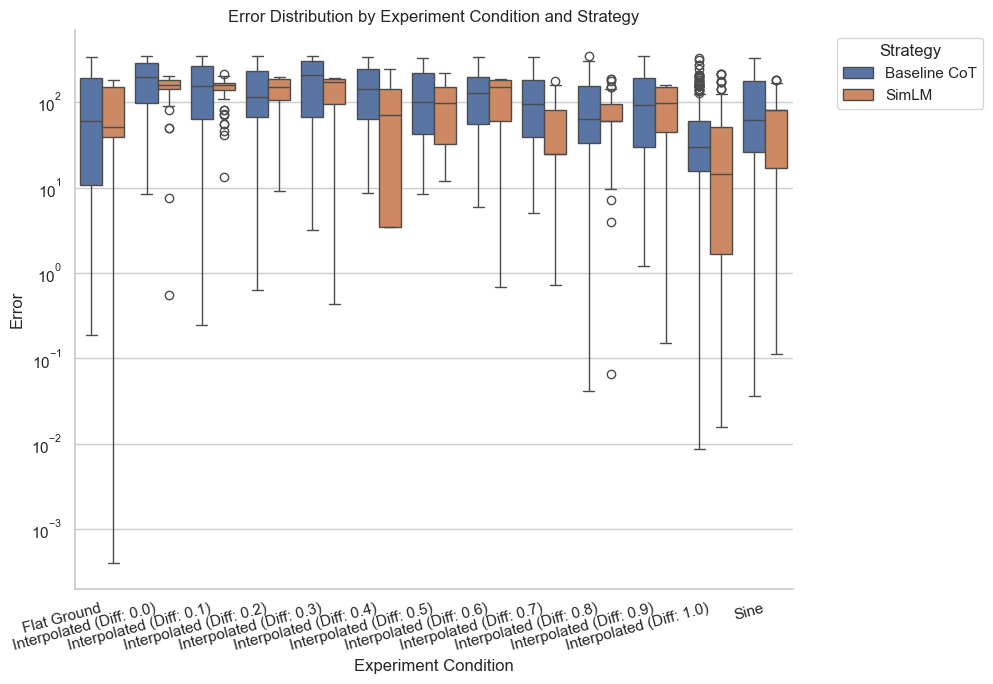

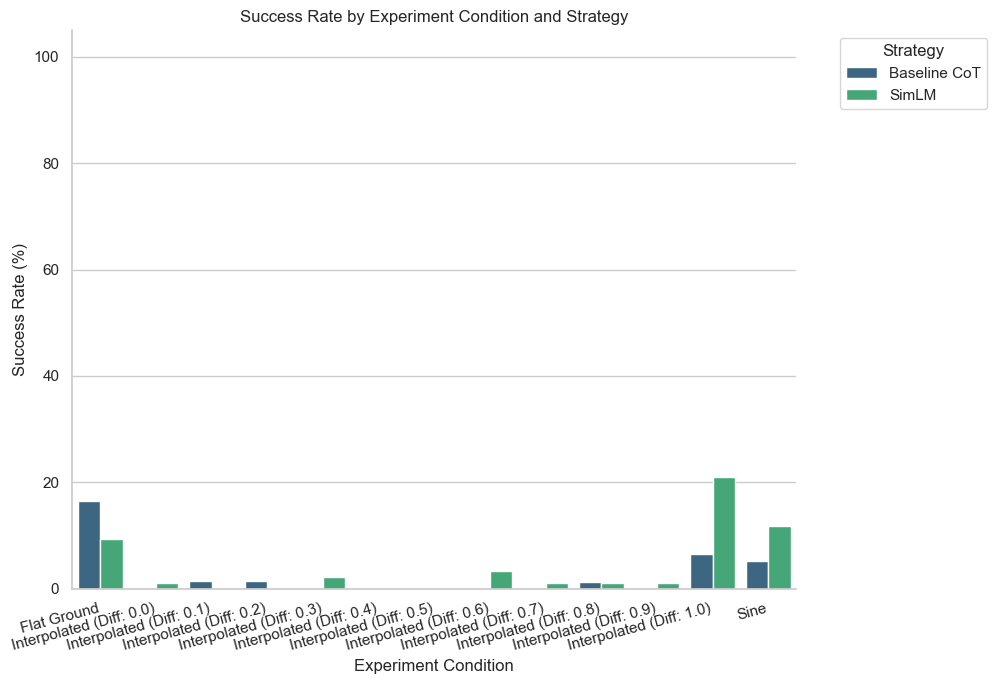

In [5]:
##### Strategy Comparison #####

# Error Distribution
plot_metric_distribution(
    results_df,
    metric_col='Error',
    group_col='Experiment Condition', 
    hue_col='Strategy',
    title='Error Distribution by Experiment Condition and Strategy',
    yscale='log' 
)

# Success Rate
plot_success_rate(
    results_df,
    group_col='Experiment Condition',
    hue_col='Strategy',
    title='Success Rate by Experiment Condition and Strategy'
)

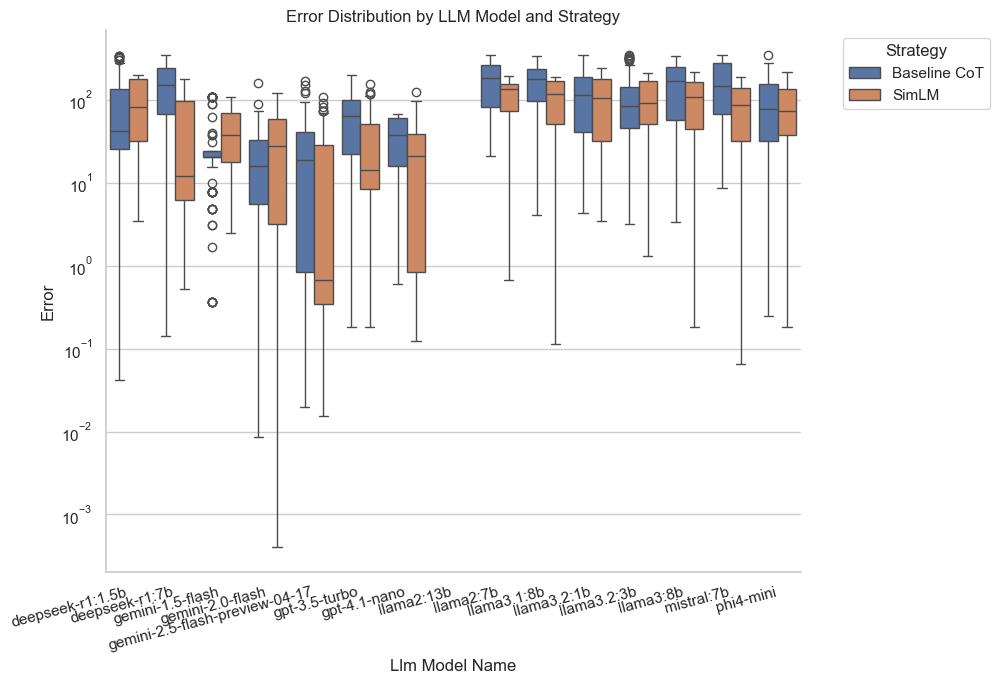

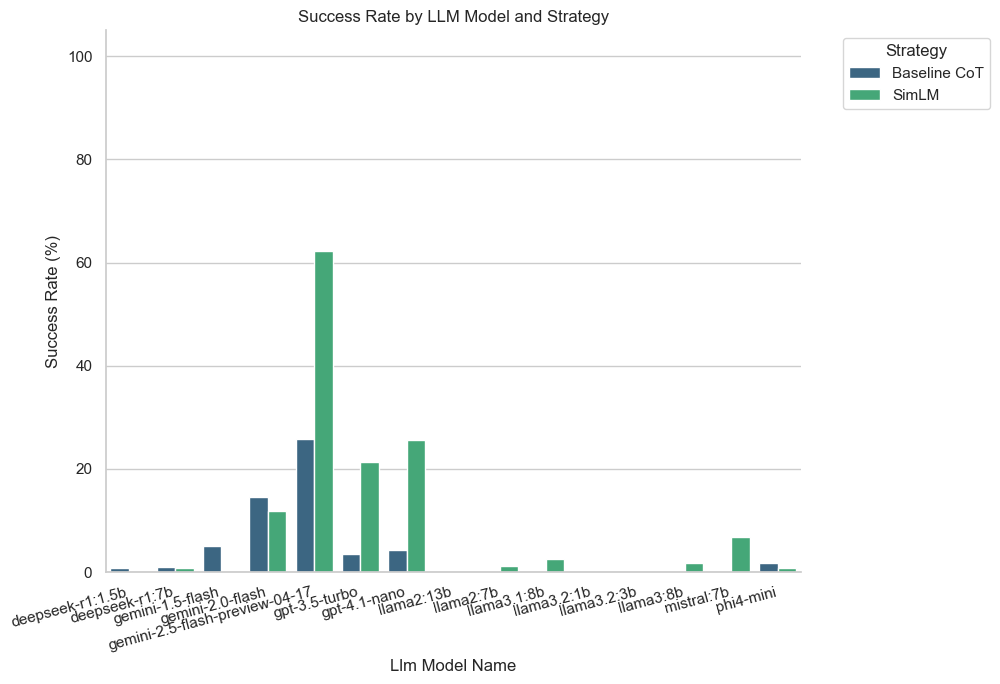

In [6]:
##### LLM Comparison #####

# Error Distribution
plot_metric_distribution(
    results_df,
    metric_col='Error',
    group_col='LLM Model Name',
    hue_col='Strategy',
    title='Error Distribution by LLM Model and Strategy',
    yscale='log'
)

# Success Rate
plot_success_rate(
    results_df,
    group_col='LLM Model Name',
    hue_col='Strategy',
    title='Success Rate by LLM Model and Strategy'
)

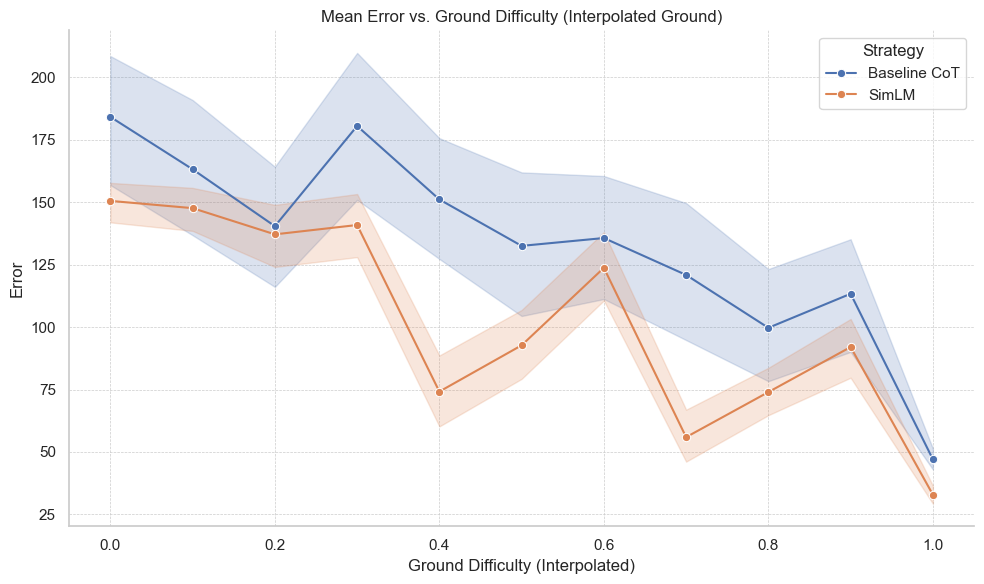

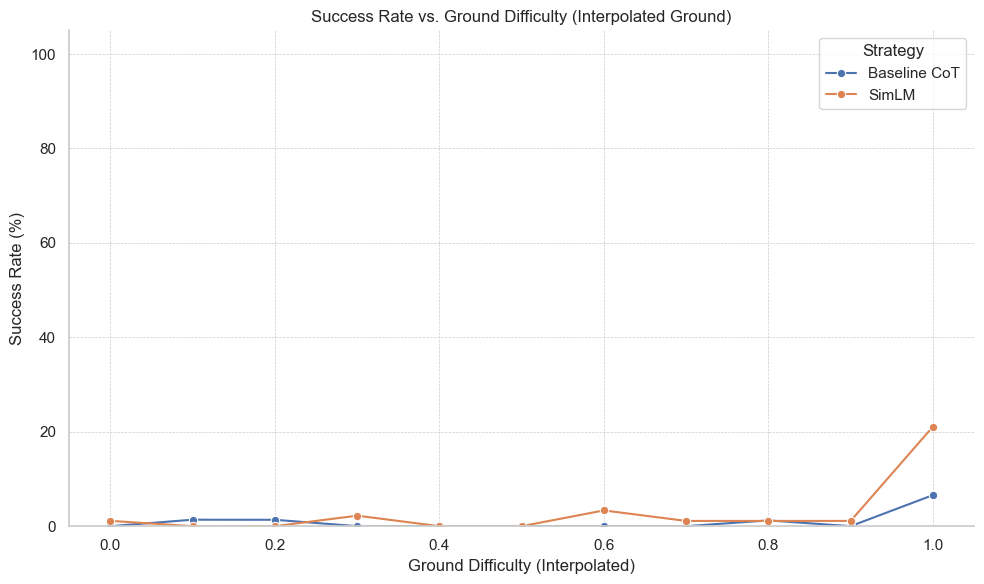

In [7]:
##### Experiment C #####

# Error vs. Difficulty
plot_metric_by_difficulty(
        results_df,
        metric_col='Error',
        title='Mean Error vs. Ground Difficulty (Interpolated Ground)'
)

# Success Rate vs. Difficulty

exp_c_df_succ = results_df[results_df['Ground Type'] == 'Interpolated'].copy()
success_by_diff = exp_c_df_succ.groupby(['Ground Difficulty', 'Strategy'], observed=False)['Success'].mean().reset_index()
success_by_diff['Success Rate (%)'] = success_by_diff['Success'] * 100

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=success_by_diff,
    x='Ground Difficulty',
    y='Success Rate (%)',
    hue='Strategy',
    marker='o'
)
plt.title('Success Rate vs. Ground Difficulty (Interpolated Ground)')
plt.xlabel("Ground Difficulty (Interpolated)")
plt.ylabel('Success Rate (%)')
plt.ylim(0, 105)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(title='Strategy')
plt.tight_layout()
plt.show()

c:\Users\alejandro\Documents\dev\CS7643-DL-Final\simlm\analysis.py:206: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Experiment Condition', bbox_to_anchor=(1.05, 1), loc='upper left')


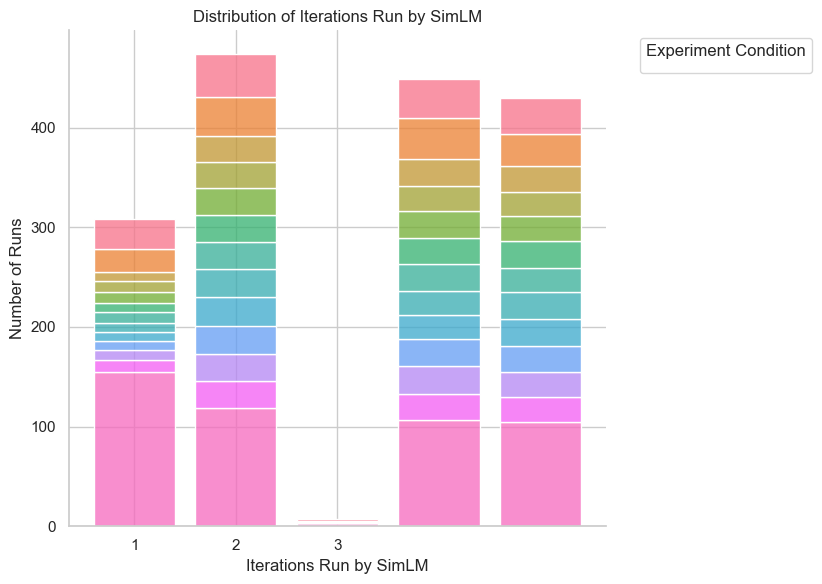

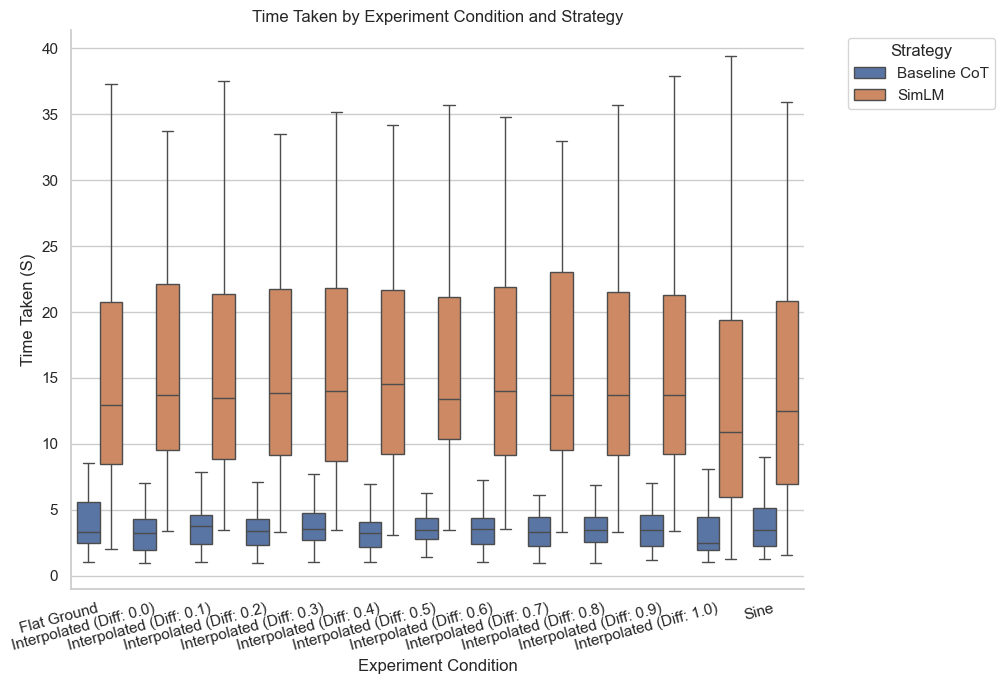

In [8]:
##### General analysis #####

# Iterations 
plot_iterations_histogram(
    results_df,
    title='Distribution of Iterations Run by SimLM'
)

# Time Taken Comparison
plot_metric_distribution(
    results_df,
    metric_col='Time Taken (s)',
    group_col='Experiment Condition',
    hue_col='Strategy',
    title='Time Taken by Experiment Condition and Strategy',
    showfliers=False 
)

Strategy                        Baseline CoT      SimLM
LLM Model Name                                         
deepseek-r1:1.5b                   92.899111  98.563483
deepseek-r1:7b                    159.895414  64.728833
gemini-1.5-flash                   33.744675  46.620324
gemini-2.0-flash                   22.158090  36.826615
gemini-2.5-flash-preview-04-17     27.538549  16.611150


c:\Users\alejandro\Documents\dev\CS7643-DL-Final\simlm\analysis.py:312: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


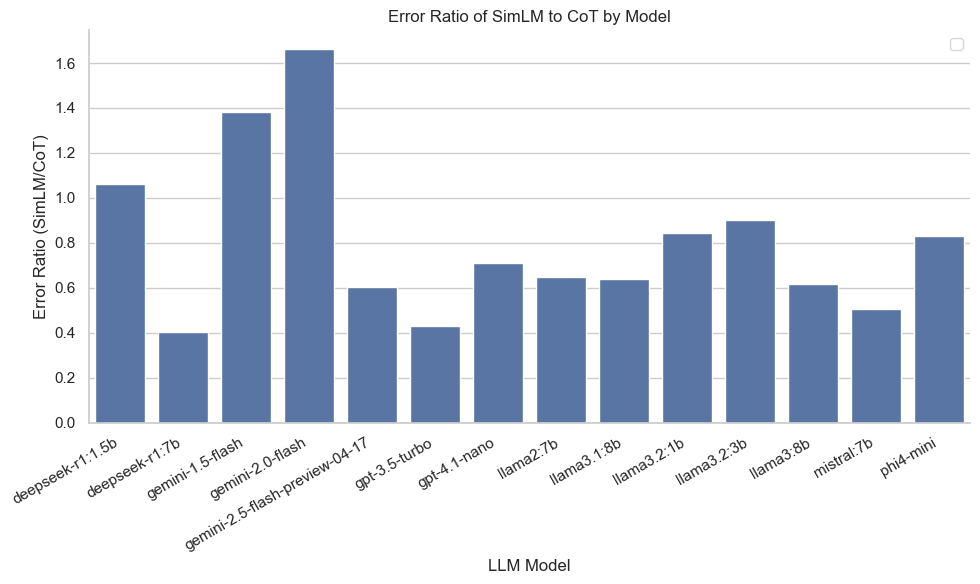

In [9]:
plot_simlm_cot_error_ratio(results_df)

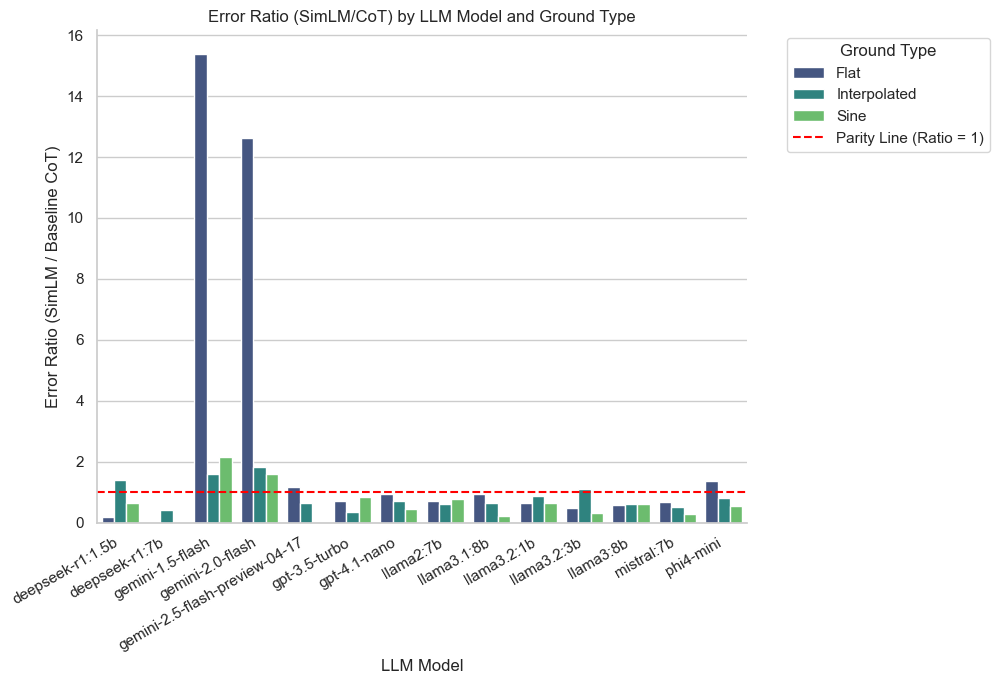

In [10]:
plot_error_ratio_by_ground(results_df)

In [11]:
summarize_average_error_by_ground(results_df)


--- Average Error by LLM Model and Ground Type ---


Ground Type,Flat,Interpolated,Sine
LLM Model Name,,,
deepseek-r1:1.5b,159.67,89.24,104.07
deepseek-r1:7b,198.79,154.39,192.95
gemini-1.5-flash,13.84,38.77,34.32
gemini-2.0-flash,3.07,32.28,29.53
gemini-2.5-flash-preview-04-17,13.18,22.26,56.66
gpt-3.5-turbo,85.37,45.05,53.61
gpt-4.1-nano,25.19,34.48,15.46
llama2:7b,171.42,123.97,111.24
llama3.1:8b,152.85,137.39,90.95


In [12]:
summarize_improvement_by_ground(results_df)


--- Improvement (Baseline CoT - SimLM) by LLM Model and Ground Type ---


Ground Type,Flat,Interpolated,Sine
LLM Model Name,,,
deepseek-r1:1.5b,214.60,-29.56,44.89
gemini-1.5-flash,-29.47,-22.51,-27.47
gemini-2.0-flash,-4.36,-20.16,-12.78
gpt-3.5-turbo,27.94,42.63,9.59
gpt-4.1-nano,1.33,11.54,12.24
llama2:7b,65.88,65.63,30.81
llama3.1:8b,8.97,59.47,119.36
llama3.2:1b,26.83,18.51,48.53
llama3.2:3b,74.62,-11.18,198.35


In [13]:
summarize_relative_improvement(results_df)


--- Relative Improvement (%) by LLM Model and Ground Type ---


Ground Type,Flat,Interpolated,Sine
LLM Model Name,,,
deepseek-r1:1.5b,80.4,-39.5,35.5
gemini-1.5-flash,-1438.8,-59.8,-115.6
gemini-2.0-flash,-1162.8,-83.4,-58.8
gpt-3.5-turbo,28.1,64.2,16.4
gpt-4.1-nano,5.1,28.6,55.8
llama2:7b,29.5,37.5,23.1
llama3.1:8b,5.7,35.1,77.4
llama3.2:1b,34.3,13.7,37.3
llama3.2:3b,52.3,-11.6,67.8


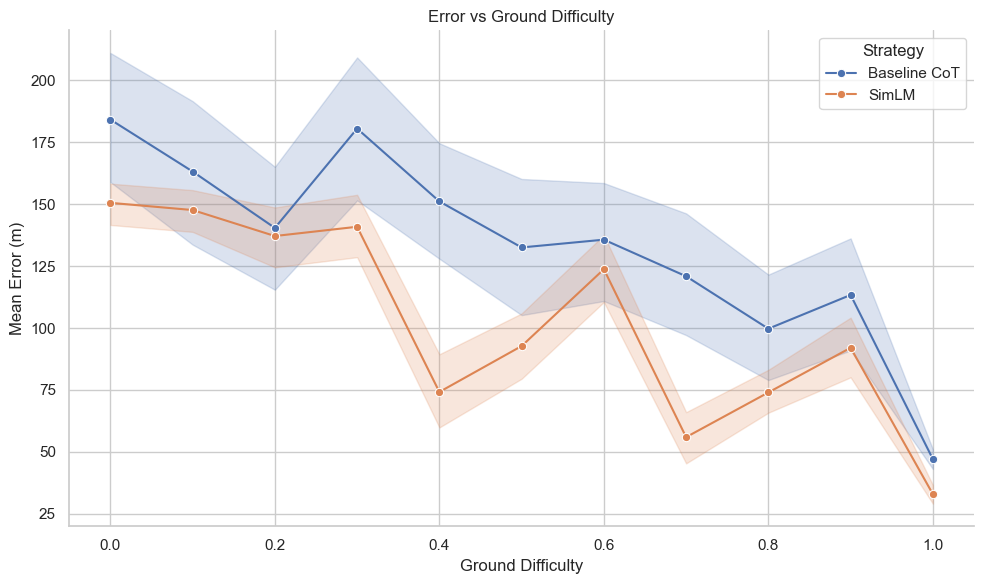

In [14]:
plot_error_vs_ground_difficulty(results_df)

In [ ]:
summarize_failure_rate(results_df)

In [ ]:
plot_iterations_vs_error(results_df)

In [ ]:
plot_histogram_error_distribution(results_df)

In [ ]:
perform_statistical_tests(results_df)